# Mind Reader: Bank Marketing Decision Tree

B.Y.T.E Data Science — Task 4

Predict term-deposit subscription and explain each prediction with SHAP.

Dataset: [UCI Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing), Moro, Rita & Cortez, CC BY 4.0. Use `bank-full.csv`, 45,211 rows, 16 original inputs and target `y`. Balances are euros. Download is automatic; raw data stays out of Git.

## Experimental design

Drop call duration: it is unknown before the call. Retain `unknown` as a category and `pdays=-1` as the no-prior-contact sentinel. Assert schema and missingness. Stratify the 80/20 train/test split with seed 42. Fit one-hot encoding only inside each training fold; numerical inputs need no scaling. Use 5-fold training CV to select depth, minimum leaf size, and class weighting by F1; cap the tree at 8 leaves. Evaluate once on the held-out test split. Scheduled contact day/month and contact number must be available at prediction time.

Because only about 12% subscribe, accuracy alone is misleading. Compare to the majority-class baseline and report positive-class precision, recall, F1, and confusion matrix.

In [1]:
"""Reproducible training and browser artifact export. Run with Python 3.12+."""
from pathlib import Path
from io import BytesIO
import hashlib
import json
import zipfile
import os
import warnings
from urllib.request import urlopen
os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd()/'.runtime/matplotlib'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
warnings.filterwarnings('ignore', message='IProgress not found.*')
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import shap
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
URL = 'https://archive.ics.uci.edu/static/public/222/bank+marketing.zip'

def load_data():
    path = ROOT / 'data/bank-full.csv'
    path.parent.mkdir(exist_ok=True)
    if not path.exists():
        with urlopen(URL, timeout=90) as response:
            outer = zipfile.ZipFile(BytesIO(response.read()))
        if 'bank-full.csv' in outer.namelist():
            raw = outer.read('bank-full.csv')
        else:
            inner = zipfile.ZipFile(BytesIO(outer.read('bank.zip')))
            raw = inner.read('bank-full.csv')
        path.write_bytes(raw)
    return pd.read_csv(path, sep=';')

def train():
    df = load_data()
    assert df.shape == (45211, 17) and not df.isna().any().any()
    # Unknown is an explicit category; pdays=-1 means no previous contact.
    X, y = df.drop(columns=['y', 'duration']), df.y.eq('yes').astype(int)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, stratify=y, random_state=42)
    categorical = X_train.select_dtypes(include=['object', 'str']).columns.tolist()
    numeric = [c for c in X if c not in categorical]
    prep = ColumnTransformer([('num', 'passthrough', numeric), ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical)])
    pipeline = Pipeline([('preprocess', prep), ('model', DecisionTreeClassifier(random_state=42, max_leaf_nodes=8))])
    # Small trees keep explanations legible and exact browser SHAP inexpensive.
    search = GridSearchCV(pipeline, {'model__max_depth':[3,4,5], 'model__min_samples_leaf':[50,150], 'model__class_weight':[None,'balanced']}, scoring='f1', cv=StratifiedKFold(5, shuffle=True, random_state=42), n_jobs=1)
    search.fit(X_train, y_train)
    pipeline = search.best_estimator_
    prep, model = pipeline.named_steps['preprocess'], pipeline.named_steps['model']
    transformed = prep.transform(X_test)
    pred = pipeline.predict(X_test)
    metrics = {k: float(fn(y_test, pred)) for k, fn in [('accuracy',accuracy_score),('precision',precision_score),('recall',recall_score),('f1',f1_score)]}
    metrics.update(train_rows=len(X_train), test_rows=len(X_test), positive_rate=float(y.mean()), baseline_accuracy=float((y_test==0).mean()), confusion_matrix=confusion_matrix(y_test,pred).tolist(), best_params=search.best_params_, cv_f1=float(search.best_score_))
    descriptors = [{'source':c,'category':None} for c in numeric]
    for c, categories in zip(categorical, prep.named_transformers_['cat'].categories_):
        descriptors.extend({'source':c,'category':str(v)} for v in categories)
    tree = model.tree_
    nodes = [{'left':int(tree.children_left[i]),'right':int(tree.children_right[i]),'feature':int(tree.feature[i]),'threshold':float(tree.threshold[i]),'weight':float(tree.weighted_n_node_samples[i]),'probability':float(tree.value[i,0,1]/tree.value[i,0].sum())} for i in range(tree.node_count)]
    importance = {c:0. for c in X}
    for descriptor, value in zip(descriptors, model.feature_importances_):
        importance[descriptor['source']] += float(value)
    ranking = sorted(importance.items(), key=lambda x:x[1], reverse=True)
    schema = []
    for c in X:
        field = {'name':c,'default':str(X_train[c].mode().iloc[0]) if c in categorical else int(X_train[c].median())}
        if c in categorical: field['options'] = sorted(X_train[c].unique().tolist())
        else: field.update(min=int(X_train[c].min()),max=int(X_train[c].max()))
        schema.append(field)
    # Path-dependent SHAP explains the raw classifier output (class-1 leaf score).
    explainer = shap.TreeExplainer(model, feature_perturbation='tree_path_dependent', model_output='raw')
    values = explainer.shap_values(transformed[:100])[:,:,1]
    base = float(explainer.expected_value[1])
    np.testing.assert_allclose(base + values.sum(axis=1), model.predict_proba(transformed[:100])[:,1], atol=1e-8)
    fixtures = [{'input':X_test.iloc[i].to_dict(),'probability':float(model.predict_proba(transformed[i:i+1])[0,1]),'shap':values[i].tolist()} for i in range(100)]
    examples = []
    for label in [0,1]:
        ids = np.flatnonzero(pred==label)
        if len(ids): examples.append({'label':'Likely subscriber' if label else 'Unlikely subscriber','input':X_test.iloc[int(ids[0])].to_dict()})
    artifact = {'nodes':nodes,'features':descriptors,'schema':schema,'metrics':metrics,'importance':ranking[:5],'base':base,'examples':examples,'weighted':model.class_weight is not None}
    for directory in ['web','outputs','tests']: (ROOT/directory).mkdir(exist_ok=True)
    for path,obj in [('web/model.json',artifact),('outputs/metrics.json',metrics),('tests/fixtures.json',fixtures)]:
        (ROOT/path).write_text(json.dumps(obj,indent=2),encoding='utf-8')
    ConfusionMatrixDisplay(confusion_matrix(y_test,pred),display_labels=['No subscription','Subscription']).plot(cmap='Blues',colorbar=False)
    plt.title('Decision tree · held-out test set'); plt.tight_layout(); plt.savefig(ROOT/'outputs/confusion_matrix.png',dpi=170); plt.close()
    fig,ax=plt.subplots(figsize=(8,4)); ax.barh([x[0] for x in ranking[:5]][::-1],[x[1] for x in ranking[:5]][::-1],color='#277568'); ax.set_xlabel('Aggregated impurity importance'); ax.set_title('Top five features'); fig.tight_layout(); fig.savefig(ROOT/'outputs/feature_importance.png',dpi=170); plt.close(fig)
    summary = f"# Model summary\n\nUCI Bank Marketing; 45,211 records. Target: term-deposit subscription.\n\n80/20 stratified split, seed 42. Preprocessing fitted inside each of five CV folds. Selection metric: F1. Test set untouched until selection.\n\nSelected parameters: `{search.best_params_}`. CV F1: {search.best_score_:.4f}.\n\n" + '\n'.join(f'- {k}: {metrics[k]:.4f}' for k in ['accuracy','precision','recall','f1','baseline_accuracy']) + f"\n\nTop five features: {ranking[:5]}.\n\nDuration excluded because it is unavailable before the call. Categorical fields use one-hot encoding, numeric fields pass through; trees do not require scaling. Unknown categories are retained. The call schedule and current campaign contact count must be known at prediction time.\n\nSHAP explains class-1 model scores using training path counts. Class weighting, if selected, makes these scores uncalibrated and unsuitable as literal purchase probabilities. Explanations describe the model, not causal effects. Historical Portuguese campaigns may not generalize to other populations or current campaigns. Random splitting does not measure future-period performance. Age is included for this educational experiment; fairness has not been evaluated.\n\nCSV SHA256: `{hashlib.sha256((ROOT/'data/bank-full.csv').read_bytes()).hexdigest()}`\n"
    (ROOT/'outputs/model_summary.md').write_text(summary,encoding='utf-8')
    print(json.dumps(metrics,indent=2))
    return pipeline, X_test, y_test, explainer, metrics




In [2]:
pipeline, X_test, y_test, explainer, metrics = train()

{
  "accuracy": 0.794426628331306,
  "precision": 0.29742033383915023,
  "recall": 0.555765595463138,
  "f1": 0.3874794069192751,
  "train_rows": 36168,
  "test_rows": 9043,
  "positive_rate": 0.11698480458295547,
  "baseline_accuracy": 0.8830034280659074,
  "confusion_matrix": [
    [
      6596,
      1389
    ],
    [
      470,
      588
    ]
  ],
  "best_params": {
    "model__class_weight": "balanced",
    "model__max_depth": 5,
    "model__min_samples_leaf": 150
  },
  "cv_f1": 0.3779370914285898
}


## Held-out evaluation and global feature ranking

Impurity importance is summed across one-hot columns to the original feature. It describes this fitted model and is not a causal ranking.

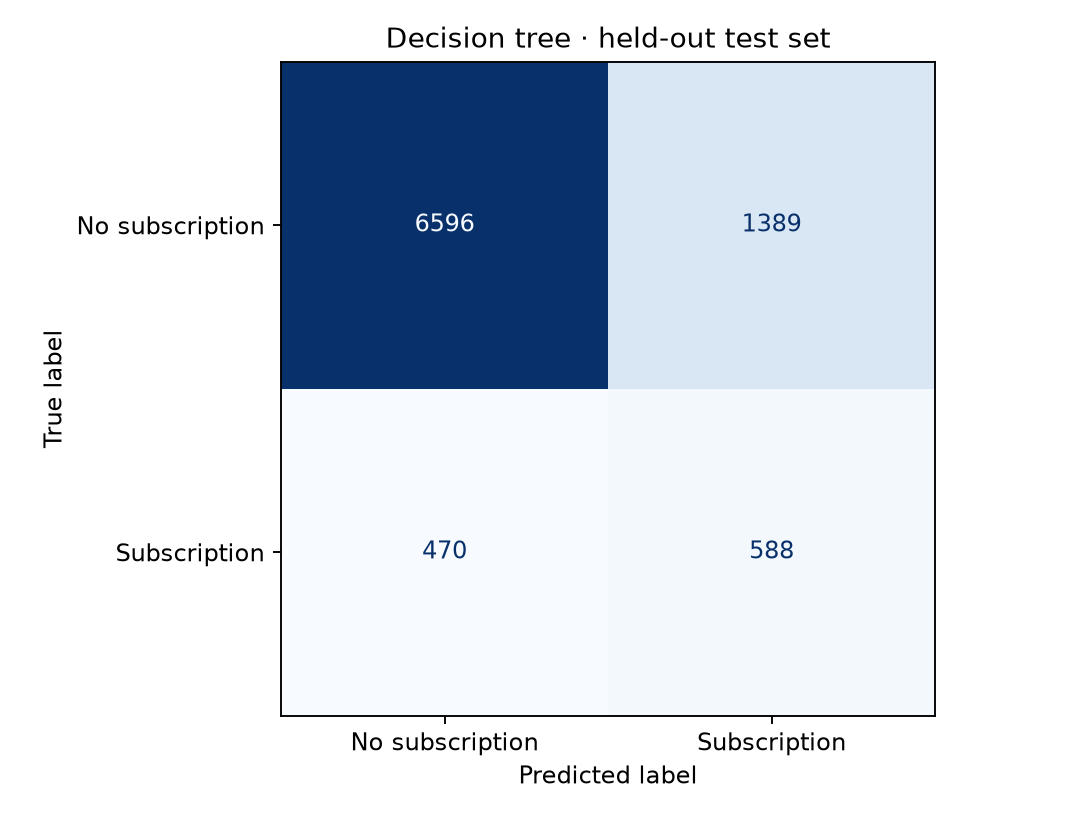

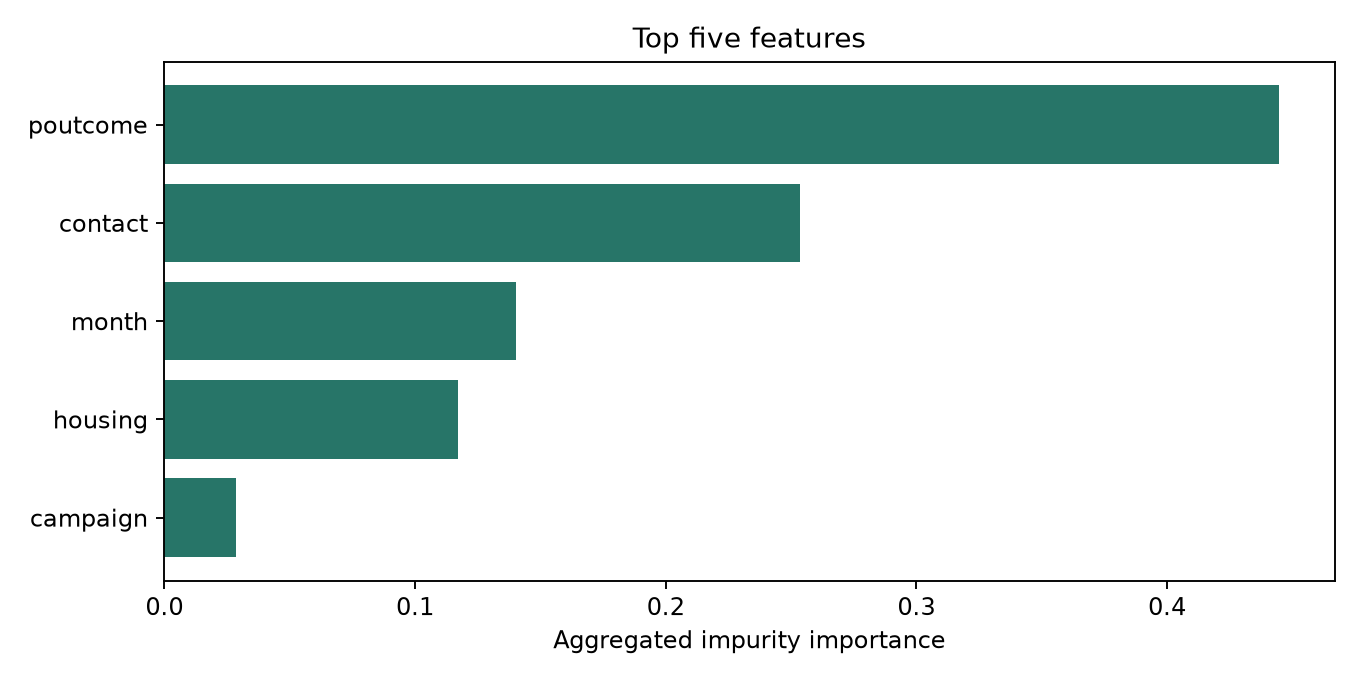

# Model summary

UCI Bank Marketing; 45,211 records. Target: term-deposit subscription.

80/20 stratified split, seed 42. Preprocessing fitted inside each of five CV folds. Selection metric: F1. Test set untouched until selection.

Selected parameters: `{'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 150}`. CV F1: 0.3779.

- accuracy: 0.7944
- precision: 0.2974
- recall: 0.5558
- f1: 0.3875
- baseline_accuracy: 0.8830

Top five features: [('poutcome', 0.4445514705543877), ('contact', 0.2535508884459269), ('month', 0.14021398506989802), ('housing', 0.11700718246384371), ('campaign', 0.028673260458385724)].

Duration excluded because it is unavailable before the call. Categorical fields use one-hot encoding, numeric fields pass through; trees do not require scaling. Unknown categories are retained. The call schedule and current campaign contact count must be known at prediction time.

SHAP explains class-1 model scores using training path counts. Class weighting, if selected, makes these scores uncalibrated and unsuitable as literal purchase probabilities. Explanations describe the model, not causal effects. Historical Portuguese campaigns may not generalize to other populations or current campaigns. Random splitting does not measure future-period performance. Age is included for this educational experiment; fairness has not been evaluated.

CSV SHA256: `d1513ec63b385506f7cfce9f2c5caa9fe99e7ba4e8c3fa264b3aaf0f849ed32d`


In [3]:
from IPython.display import display, Image, Markdown
display(Image(filename=str(ROOT/'outputs/confusion_matrix.png')))
display(Image(filename=str(ROOT/'outputs/feature_importance.png')))
display(Markdown((ROOT/'outputs/model_summary.md').read_text(encoding='utf-8')))

## Explain an individual prediction

TreeExplainer uses tree-path-dependent training counts to explain class-1 scores. The baseline plus SHAP contributions equals the score. For a weighted tree, scores are not calibrated real-world probabilities. SHAP signals describe model associations; they do not prove why a customer acts.

In [4]:
row = X_test.iloc[[0]]
z = pipeline.named_steps['preprocess'].transform(row)
phi = explainer.shap_values(z)[0,:,1]
score = pipeline.predict_proba(row)[0,1]
assert abs(explainer.expected_value[1] + phi.sum() - score) < 1e-8
artifact = json.loads((ROOT/'web/model.json').read_text())
contributions = {}
for f, value in zip(artifact['features'], phi):
    contributions[f['source']] = contributions.get(f['source'], 0) + float(value)
yes = score > .5
ranked = sorted(contributions.items(), key=lambda item: abs(item[1]), reverse=True)
reasons = [(k,v) for k,v in ranked if (v>0 if yes else v<0)][:2]
print(f'The model predicts this customer will {"" if yes else "not "}subscribe because ' + ' and '.join(f'{k}={row.iloc[0][k]} pushes the subscription score {"up" if v>0 else "down"}' for k,v in reasons) + '.')
print(f'Model score: {score:.3f}; baseline: {explainer.expected_value[1]:.3f}')
display(pd.DataFrame(ranked, columns=['Feature', 'SHAP contribution']))

The model predicts this customer will not subscribe because contact=unknown pushes the subscription score down and poutcome=unknown pushes the subscription score down.
Model score: 0.243; baseline: 0.500


,Feature,SHAP contribution
0,contact,-0.165509
1,poutcome,-0.058721
2,housing,-0.043468
3,month,0.014379
4,pdays,-0.001785
5,campaign,-0.001521
6,age,0.000000
7,balance,0.000000
8,day,0.000000
9,previous,0.000000


## Limitations and deployment

Historical data and a random split do not establish future campaign performance. The small tree trades flexibility for interpretability. Class-weighted scores require calibration before interpreting them as probabilities. Fairness has not been audited. This is a learning demonstration, not a customer targeting recommendation.

The browser receives the actual fitted tree as JSON and computes exact Shapley values over the at-most-seven split features using the same path-count value function. `node tests/model.test.mjs` checks 100 predictions and complete SHAP vectors against Python. This lets Vercel serve a static demo without a Python API.